# Customer Segmentation: Rules vs. K-means Clustering

**Student project** — Bachelor's in Data Analysis (in progress)

This week in my classes I studied three topics:
1. **Decision structures in Python** (`if / elif / else`)
2. **Data preprocessing & advanced plotting** (Matplotlib + Seaborn)
3. **Clustering with K-means**

I wanted to put them together in one small project. I work in customer experience, so I asked myself:

> If I group customers with rules that *I* write, will I get the same groups that the *data* finds by itself?

⚠️ The dataset is **synthetic** (generated by `data/generate_data.py`). No real customer data is used.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

sys.path.append("../src")
from kmeans_scratch import kmeans, sse   # my own implementation

sns.set_style("whitegrid")
pd.set_option("display.precision", 2)

## 1. Load the data

In [2]:
df = pd.read_csv("../data/customers_raw.csv")
print("Shape:", df.shape)
df.head()

Shape: (470, 6)


  customer_id  tenure_months  monthly_spend_sar  support_calls_6m  data_usage_gb plan_type
0       C1000              6              90.16                 5           11.5   Prepaid
1       C1001             56             496.68                 0           37.3   Prepaid
2       C1002              3             150.35                 9            9.5   Prepaid
3       C1003             39              74.26                 1            5.0  Postpaid
4       C1004              1             169.63                 7           11.8  POSTPAID

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        470 non-null    str    
 1   tenure_months      470 non-null    int64  
 2   monthly_spend_sar  455 non-null    float64
 3   support_calls_6m   470 non-null    int64  
 4   data_usage_gb      457 non-null    float64
 5   plan_type          470 non-null    str    
dtypes: float64(2), int64(2), str(2)
memory usage: 22.2 KB


In [4]:
df.describe()

       tenure_months  monthly_spend_sar  support_calls_6m  data_usage_gb
count         470.00             455.00            470.00         457.00
mean           27.42             266.63              2.15          35.87
std            18.66             325.91              2.46          31.75
min             1.00              61.37              0.00           0.50
25%            13.00             112.78              0.00           8.60
50%            24.00             200.51              1.00          28.40
75%            41.00             343.02              3.00          61.80
max            82.00            4000.00             13.00         134.30

Already I can see some problems:
- `monthly_spend_sar` max is **4000 SAR** while the 75% value is much lower → probably outliers
- some columns have fewer non-null values → missing data
- I should check duplicates and the text column `plan_type`

## 2. Data cleaning

### 2.1 Duplicates

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 10
Shape after removing duplicates: (460, 6)


### 2.2 Structural errors (inconsistent text)

In [6]:
print("Before:", df["plan_type"].unique())
df["plan_type"] = df["plan_type"].str.strip().str.lower()
print("After: ", df["plan_type"].unique())

Before: <StringArray>
[   'Prepaid',   'Postpaid',   'POSTPAID', ' Postpaid ',  ' Prepaid ',
   'postpaid',    'prepaid',    'PREPAID']
Length: 8, dtype: str
After:  <StringArray>
['prepaid', 'postpaid']
Length: 2, dtype: str


### 2.3 Missing values

I used **median imputation** instead of the mean, because spend has outliers and the mean is affected by them (we saw this in the statistics class too).

In [7]:
print(df.isnull().sum())

for col in ["monthly_spend_sar", "data_usage_gb"]:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing after imputation:", df.isnull().sum().sum())

customer_id           0
tenure_months         0
monthly_spend_sar    14
support_calls_6m      0
data_usage_gb        12
plan_type             0
dtype: int64

Missing after imputation: 0


### 2.4 Outliers (IQR method)

A point is a potential outlier if it is below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

In [8]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low, high = iqr_bounds(df["monthly_spend_sar"])
outliers = df[(df["monthly_spend_sar"] < low) | (df["monthly_spend_sar"] > high)]
print(f"Bounds: {low:.1f} to {high:.1f} SAR")
print("Number of outliers:", len(outliers))
outliers[["customer_id", "monthly_spend_sar"]]

Bounds: -211.5 to 653.9 SAR
Number of outliers: 6


    customer_id  monthly_spend_sar
89        C1089             2750.0
203       C1203             2500.0
205       C1205             3100.0
214       C1214             1990.0
349       C1349             4000.0
367       C1367             2200.0

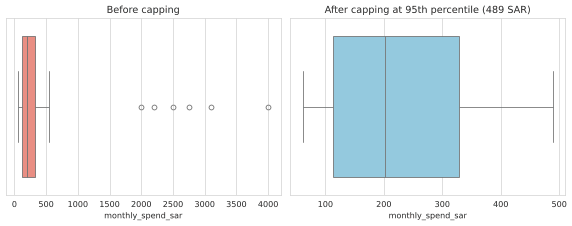

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=df["monthly_spend_sar"], ax=axs[0], color="salmon")
axs[0].set_title("Before capping")

# capping (winsorization): replace extreme values with the 95th percentile
cap = df["monthly_spend_sar"].quantile(0.95)
df["monthly_spend_sar"] = df["monthly_spend_sar"].clip(upper=cap)

sns.boxplot(x=df["monthly_spend_sar"], ax=axs[1], color="skyblue")
axs[1].set_title(f"After capping at 95th percentile ({cap:.0f} SAR)")
plt.tight_layout()
plt.savefig("../images/outliers_boxplot.png", dpi=110)
plt.show()

I chose **capping** instead of deleting the rows, so I don't lose customers from the dataset.

## 3. Quick EDA

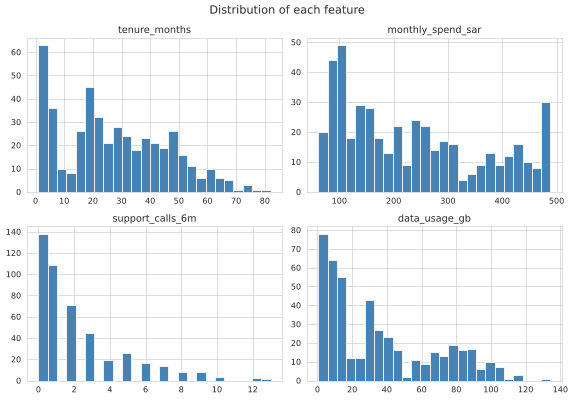

In [10]:
features = ["tenure_months", "monthly_spend_sar", "support_calls_6m", "data_usage_gb"]

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axs.flat, features):
    ax.hist(df[col], bins=25, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.suptitle("Distribution of each feature", fontsize=14)
plt.tight_layout()
plt.show()

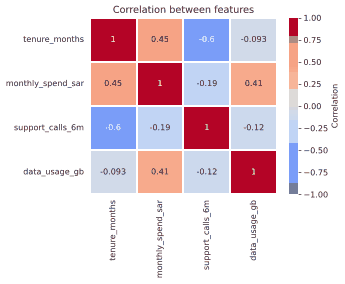

In [11]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation between features")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=110)
plt.show()

Tenure and spend are positively correlated, and support calls are negatively correlated with tenure (newer customers call more).

## 4. Approach A: Rule-based segments (if / elif / else)

This is how I would group customers if I just wrote rules from my own experience. The thresholds are my assumptions.

In [12]:
def rule_segment(row):
    if row["monthly_spend_sar"] >= 300:
        return "High value"
    elif row["support_calls_6m"] >= 4:
        return "Needs attention"
    elif row["tenure_months"] < 6:
        return "New"
    else:
        return "Standard"

df["rule_segment"] = df.apply(rule_segment, axis=1)
df["rule_segment"].value_counts()

rule_segment
Standard           214
High value         136
Needs attention     90
New                 20

## 5. Approach B: K-means clustering

### 5.1 Normalization
K-means uses distance, so a feature with big numbers (spend in hundreds) would dominate a feature with small numbers (calls 0–10). I used **min-max normalization**: `(x - min) / (max - min)`.

In [13]:
X = df[features]
X_scaled = (X - X.min()) / (X.max() - X.min())
X_scaled.describe().loc[["min", "max"]]

     tenure_months  monthly_spend_sar  support_calls_6m  data_usage_gb
min            0.0                0.0               0.0            0.0
max            1.0                1.0               1.0            1.0

### 5.2 Testing my own K-means vs scikit-learn
I compared my implementation from `src/kmeans_scratch.py` with scikit-learn.

In [14]:
labels_mine, cents_mine, iters = kmeans(X_scaled.values, k=4, seed=1)
print(f"My K-means      -> SSE = {sse(X_scaled.values, labels_mine, cents_mine):.2f} ({iters} iterations)")

km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_scaled)
print(f"scikit-learn    -> SSE = {km.inertia_:.2f}")

My K-means      -> SSE = 40.68 (6 iterations)
scikit-learn    -> SSE = 18.45


At first I thought my code had a bug, because my SSE was much higher than scikit-learn's. 🤔

### 5.3 Initial centroids matter!
Then I remembered from the lecture that random initial centroids can give different results. Let me test it with 10 different random starts:

In [15]:
results = []
for seed in range(10):
    lab, cen, _ = kmeans(X_scaled.values, k=4, seed=seed)
    results.append(sse(X_scaled.values, lab, cen))

print("SSE for 10 different random starts:")
print(np.round(results, 2))
print(f"Best: {min(results):.2f} | Worst: {max(results):.2f}")

SSE for 10 different random starts:
[34.22 40.68 18.45 18.45 34.22 18.45 41.04 41.62 18.45 18.45]
Best: 18.45 | Worst: 41.62


So my code was fine: the best runs reach the same SSE as scikit-learn (18.45), but some runs get stuck in a worse solution. That's why scikit-learn uses `n_init=10` (runs 10 times and keeps the best) and a smarter initialization (k-means++).

### 5.4 Choosing K (Elbow method)

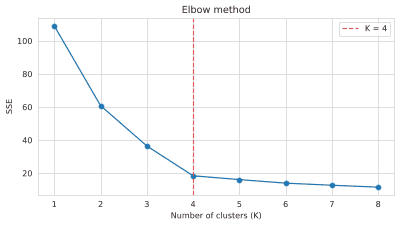

In [16]:
k_values = range(1, 9)
sse_values = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled).inertia_ for k in k_values]

plt.figure(figsize=(7, 4))
plt.plot(k_values, sse_values, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("SSE")
plt.title("Elbow method")
plt.axvline(4, color="red", linestyle="--", alpha=0.6, label="K = 4")
plt.legend()
plt.tight_layout()
plt.savefig("../images/elbow.png", dpi=110)
plt.show()

SSE always goes down when K increases, but after **K = 4** the improvement becomes small. So I chose K = 4.

### 5.5 Final model and cluster profiles

In [17]:
km = KMeans(n_clusters=4, n_init=10, random_state=42)
df["cluster"] = km.fit_predict(X_scaled)

profile = df.groupby("cluster")[features].mean().round(1)
profile["customers"] = df["cluster"].value_counts().sort_index()
profile

         tenure_months  monthly_spend_sar  support_calls_6m  data_usage_gb  customers
cluster                                                                              
0                 19.0              255.2               1.9           80.0        129
1                  4.0              145.7               5.7           12.6        101
2                 48.4              423.8               1.0           34.9        115
3                 36.5               99.3               0.4            7.4        115

Looking at the averages, I gave each cluster a name (this part is my interpretation):

In [18]:
def name_cluster(row):
    if row["monthly_spend_sar"] == profile["monthly_spend_sar"].max():
        return "Loyal high spenders"
    if row["support_calls_6m"] == profile["support_calls_6m"].max():
        return "New & calling support"
    if row["data_usage_gb"] == profile["data_usage_gb"].max():
        return "Heavy data users"
    return "Low engagement"

cluster_names = profile.apply(name_cluster, axis=1).to_dict()
df["cluster_name"] = df["cluster"].map(cluster_names)
cluster_names

{0: 'Heavy data users', 1: 'New & calling support', 2: 'Loyal high spenders', 3: 'Low engagement'}

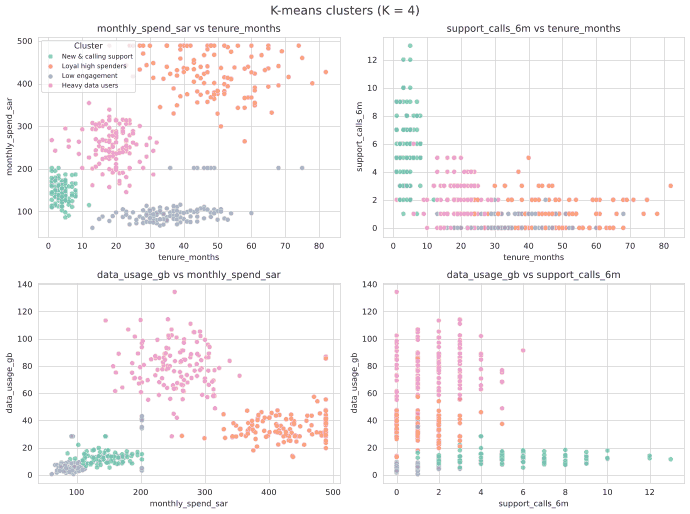

In [19]:
pairs = [("tenure_months", "monthly_spend_sar"),
         ("tenure_months", "support_calls_6m"),
         ("monthly_spend_sar", "data_usage_gb"),
         ("support_calls_6m", "data_usage_gb")]

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
for ax, (x, y) in zip(axs.flat, pairs):
    sns.scatterplot(data=df, x=x, y=y, hue="cluster_name", palette="Set2",
                    alpha=0.8, s=35, ax=ax, legend=(ax is axs[0, 0]))
    ax.set_title(f"{y} vs {x}")
axs[0, 0].legend(title="Cluster", fontsize=8, loc="upper left")
plt.suptitle("K-means clusters (K = 4)", fontsize=15)
plt.tight_layout()
plt.savefig("../images/clusters_subplots.png", dpi=110)
plt.show()

## 6. Rules vs. Clusters — do they agree?

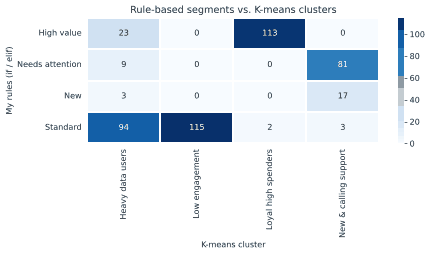

In [20]:
comparison = pd.crosstab(df["rule_segment"], df["cluster_name"])

plt.figure(figsize=(8, 4.5))
sns.heatmap(comparison, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Rule-based segments vs. K-means clusters")
plt.ylabel("My rules (if / elif)")
plt.xlabel("K-means cluster")
plt.tight_layout()
plt.savefig("../images/rules_vs_clusters.png", dpi=110)
plt.show()

In [21]:
comparison

cluster_name     Heavy data users  Low engagement  Loyal high spenders  New & calling support
rule_segment                                                                                 
High value                     23               0                  113                      0
Needs attention                 9               0                    0                     81
New                             3               0                    0                     17
Standard                       94             115                    2                      3

## 7. What I found

- My **"High value"** rule mostly matched the *Loyal high spenders* cluster (113 customers), but it also included 23 *Heavy data users* — spend alone doesn't tell the full story.
- My **"Standard"** rule was a big mixed group (214 customers). K-means split it mainly into *Heavy data users* and *Low engagement* (e.g. *Low engagement* customers who spend little and use almost no data — these could be a churn risk).
- **"Needs attention"** and the *New & calling support* cluster overlap a lot (81 customers), so my rule was reasonable there.
- My **"New"** rule caught only 20 customers, even though the *New & calling support* cluster has 101. The reason is the **order of my `elif`s**: most new customers call support a lot, so they were already caught by the "Needs attention" condition before reaching the "New" check. Good reminder from the decision structures lecture: in `if / elif`, only the first true condition runs!
- Rules are easy to explain, but they only find what I already expect. Clustering can show groups I didn't think about.

## 8. What I learned
- Cleaning comes first: the outliers would have pulled the centroids and the mean spend.
- Normalization is necessary before K-means.
- K-means depends on the initial centroids and on choosing K.
- Writing K-means myself helped me understand it much better than just calling `KMeans()`.

## 9. Limitations & next steps
- The data is synthetic and the clusters are quite clean. Real data will be messier.
- K-means assumes round (globular) clusters of similar size; I want to try **DBSCAN** and **hierarchical clustering** next.
- Use the **silhouette score** to choose K, not only the elbow.
- Build a small dashboard (Power BI or Tableau) on top of the segments.